1. Import Libraries & Load Cleaned Data
2. Dataset Overview
3. Revenue Analysis
4. Order Analysis
5. Customer Analysis
6. Product Analysis
7. Country Analysis
8. Time-Based Analysis
9. Customer Purchase Behavior
10. Key Business Insights

1. Import Libraries & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load cleaned dataset
df = pd.read_csv("online_retail_cleaned.csv")

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (392692, 16)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month,Day_Name,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,2010-12,Wednesday,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,2010-12,Wednesday,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8


2. Dataset Overview

In [8]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDate Range:")
print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

print("\nNumber of Unique Customers:",df["CustomerID"].nunique())

print("\nNumber of Unique Orders:",df["InvoiceNo"].nunique())

print("\nNumber of Unique Products:",df["StockCode"].nunique())

print("\nNumber of Countries:",df["Country"].nunique())

Dataset Shape: (392692, 16)

Data Types:
InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
Revenue               float64
Year                    int64
Month                   int64
Month_Name             object
Year_Month             object
Day_Name               object
Day                     int64
Hour                    int64
dtype: object

Date Range:
Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00

Number of Unique Customers: 4338

Number of Unique Orders: 18532

Number of Unique Products: 3665

Number of Countries: 37


In [2]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Month,Day,Hour
count,392692.000000,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,13087.063759,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661


3. Revenue Analysis

In [3]:
# Total Revenue

total_revenue = df["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


In [4]:
# Monthly Revenue

monthly_revenue = (df.groupby("Year_Month")["Revenue"].sum().reset_index())

monthly_revenue

,Year_Month,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


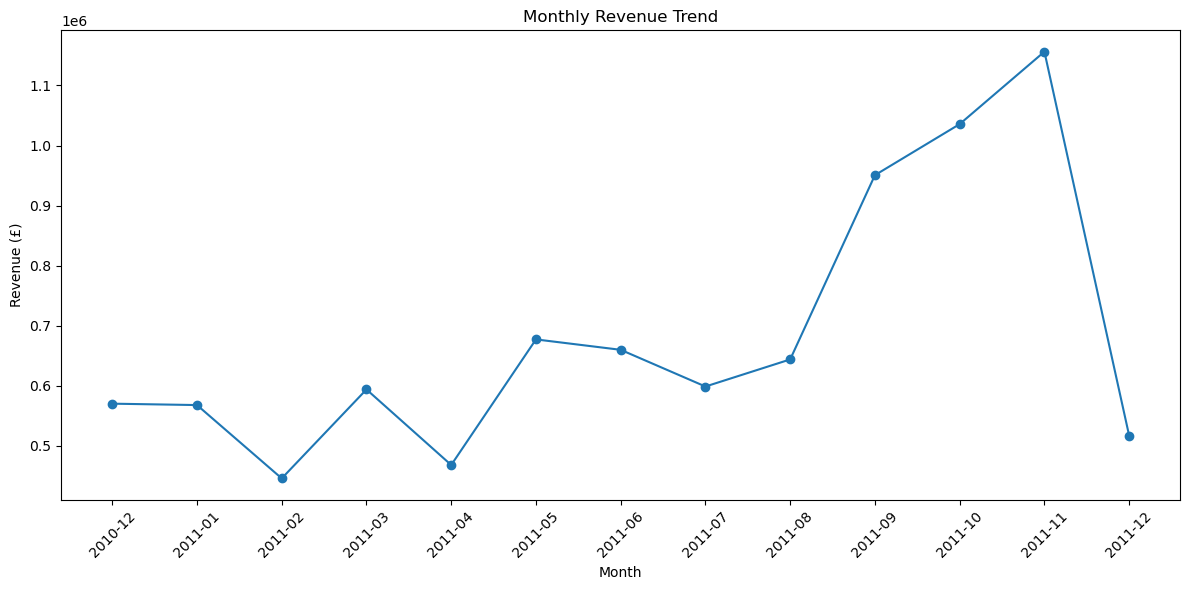

In [5]:
# Visualize monthly revenue

plt.figure(figsize=(12, 6))

plt.plot(monthly_revenue["Year_Month"],monthly_revenue["Revenue"],marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [6]:
# Monthly Revenue Growth

monthly_revenue["Revenue_Growth_%"] = (monthly_revenue["Revenue"].pct_change() * 100)

monthly_revenue

,Year_Month,Revenue,Revenue_Growth_%
0,2010-12,570422.730,NaN
1,2011-01,568101.310,-0.406965
2,2011-02,446084.920,-21.477928
3,2011-03,594081.760,33.176831
4,2011-04,468374.331,-21.159954
5,2011-05,677355.150,44.618333
6,2011-06,660046.050,-2.555395
7,2011-07,598962.901,-9.254377
8,2011-08,644051.040,7.527701
9,2011-09,950690.202,47.611003


4. Order Analysis

In [7]:
# Total Orders

total_orders = df["InvoiceNo"].nunique()

print("Total Orders:", total_orders)

Total Orders: 18532


In [8]:
# Average Order Value
# Important: calculate this at the order level, not simply by averaging transaction rows.

average_order_value = (df.groupby("InvoiceNo")["Revenue"].sum().mean())

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £479.56


In [9]:
# Orders per Month
monthly_orders = (df.groupby("Year_Month")["InvoiceNo"].nunique().reset_index(name="Total_Orders"))

monthly_orders

,Year_Month,Total_Orders
0,2010-12,1400
1,2011-01,987
2,2011-02,997
3,2011-03,1321
4,2011-04,1149
5,2011-05,1555
6,2011-06,1393
7,2011-07,1331
8,2011-08,1280
9,2011-09,1755


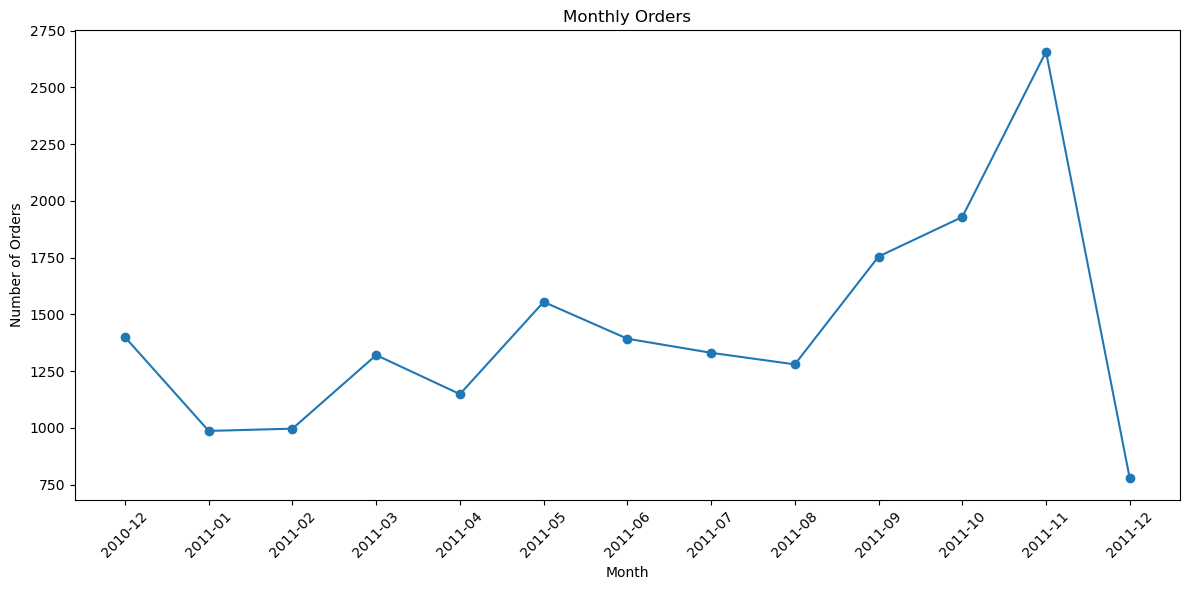

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_orders["Year_Month"],monthly_orders["Total_Orders"], marker="o")

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

5. Customer Analysis

In [11]:
# Total Unique Customers

total_customers = df["CustomerID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 4338


In [12]:
# Revenue per Customer

customer_revenue = (df.groupby("CustomerID")
            .agg(Total_Revenue=("Revenue", "sum"),
                 Total_Orders=("InvoiceNo", "nunique"),
                 Total_Quantity=("Quantity", "sum")).reset_index())

customer_revenue.head()

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity
0,12346,77183.60,1,74215
1,12347,4310.00,7,2458
2,12348,1797.24,4,2341
3,12349,1757.55,1,631
4,12350,334.40,1,197


In [13]:
# Top 10 Customers by Revenue

top_customers = (customer_revenue.sort_values(by="Total_Revenue",ascending=False).head(10))

top_customers

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity
1689,14646,280206.02,73,196915
4201,18102,259657.30,60,64124
3728,17450,194390.79,46,69973
3008,16446,168472.50,2,80997
1879,14911,143711.17,201,80240
55,12415,124914.53,21,77374
1333,14156,117210.08,55,57768
3771,17511,91062.38,31,64549
2702,16029,80850.84,63,40108
0,12346,77183.60,1,74215


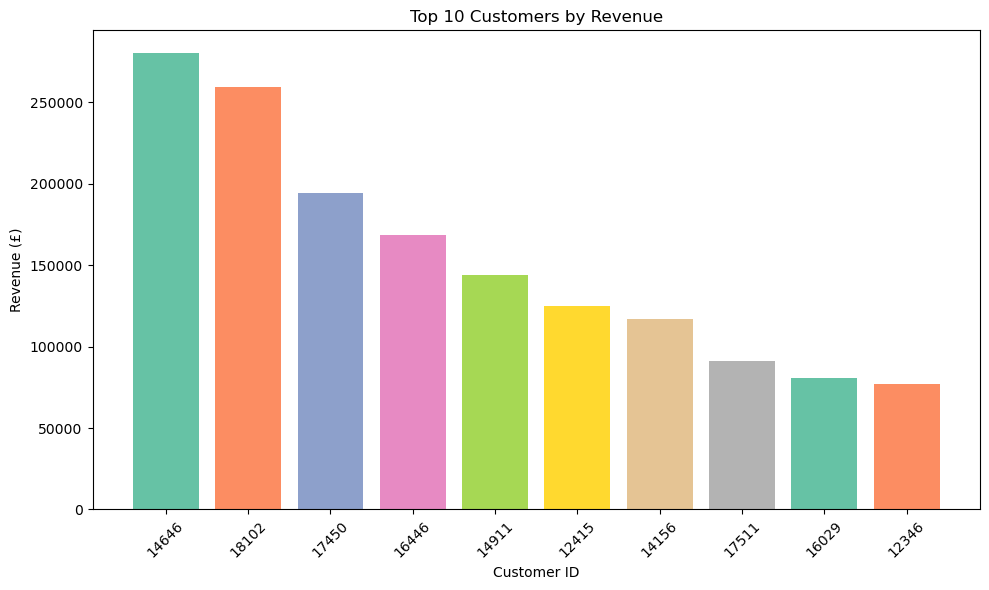

In [14]:
# Visualization

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Set2", n_colors=len(df))

plt.bar(top_customers["CustomerID"].astype(str),top_customers["Total_Revenue"], color = colors)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

6. Repeat Customer Analysis

In [15]:
# First, calculate how many unique orders each customer has.

customer_orders = (df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index(name="Order_Count"))

customer_orders.head()

,CustomerID,Order_Count
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [16]:
# New / One-Time vs Repeat Customers

one_time_customers = customer_orders[customer_orders["Order_Count"] == 1].shape[0]

repeat_customers = customer_orders[customer_orders["Order_Count"] > 1].shape[0]

print("One-Time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)

One-Time Customers: 1493
Repeat Customers: 2845


In [17]:
# Repeat Customer Rate

repeat_customer_rate = (repeat_customers / total_customers) * 100

print( f"Repeat Customer Rate: "f"{repeat_customer_rate:.2f}%")

Repeat Customer Rate: 65.58%


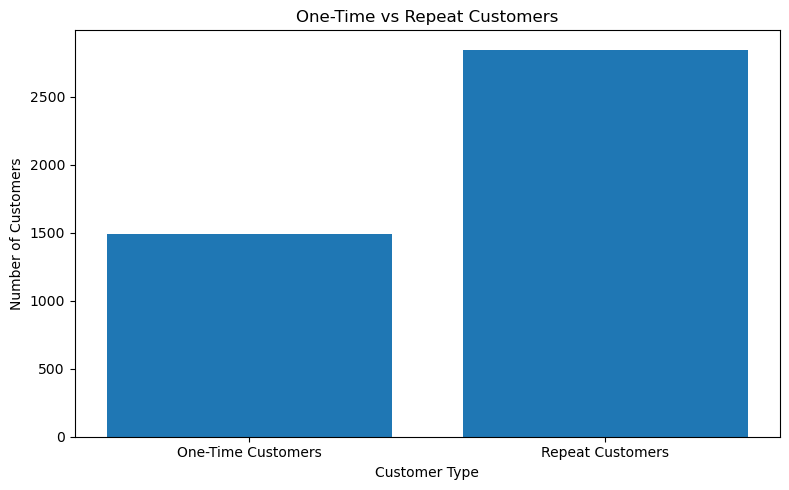

In [18]:
# Visualization

customer_type = pd.DataFrame({"Customer_Type": ["One-Time Customers","Repeat Customers"],"Count": [one_time_customers,repeat_customers]})

plt.figure(figsize=(8, 5))

plt.bar(customer_type["Customer_Type"],customer_type["Count"])

plt.title("One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

7. Product Analysis

In [19]:
# Total Products

total_products = df["StockCode"].nunique()

print("Total Unique Products:", total_products)

Total Unique Products: 3665


In [20]:
# Top 10 Products by Revenue

top_products_revenue = (
    df.groupby(["StockCode", "Description"])["Revenue"].sum().reset_index().sort_values(by="Revenue",ascending=False).head(10))

top_products_revenue

,StockCode,Description,Revenue
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1318,22423,REGENCY CAKESTAND 3 TIER,142264.75
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3444,85099B,JUMBO BAG RED RETROSPOT,85040.54
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
3896,POST,POSTAGE,77803.96
2799,47566,PARTY BUNTING,68785.23
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03
3894,M,Manual,53419.93
2006,23084,RABBIT NIGHT LIGHT,51251.24


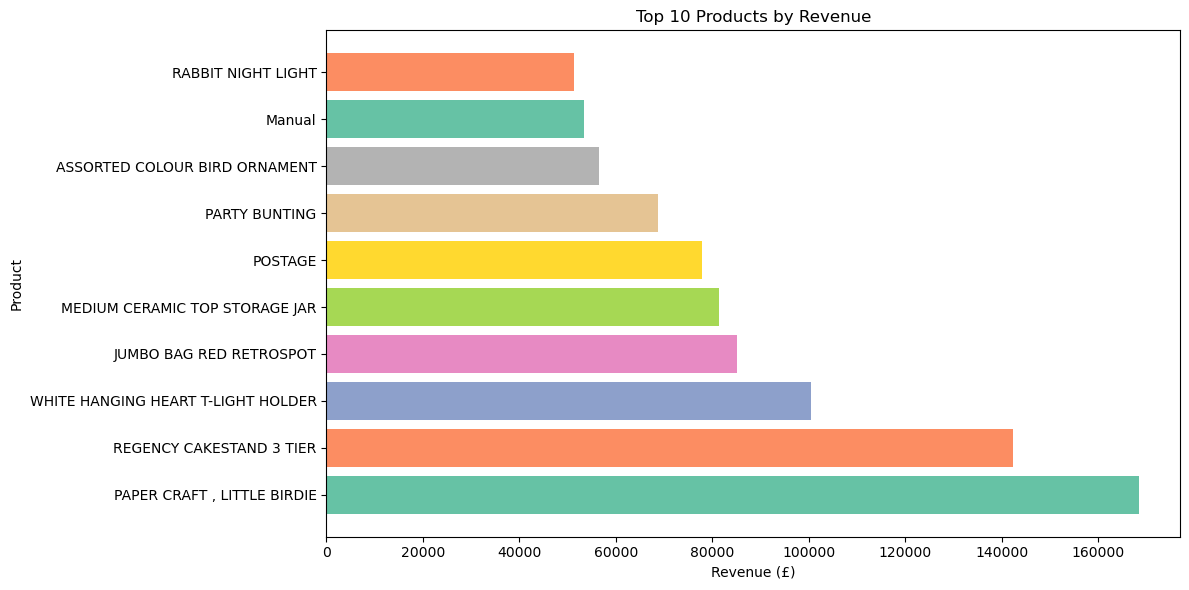

In [21]:
# Visualization

plt.figure(figsize=(12, 6))
colors = sns.color_palette("Set2", n_colors=len(df))

plt.barh(top_products_revenue["Description"],top_products_revenue["Revenue"], color = colors)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [22]:
# Top Products by Quantity Sold

top_products_quantity = (df.groupby(["StockCode", "Description"])["Quantity"]
                        .sum().reset_index().sort_values(by="Quantity",ascending=False).head(10))

top_products_quantity

,StockCode,Description,Quantity
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3444,85099B,JUMBO BAG RED RETROSPOT,46078
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,35263
432,21212,PACK OF 72 RETROSPOT CAKE CASES,33670
1108,22197,POPCORN HOLDER,30919
2006,23084,RABBIT NIGHT LIGHT,27153
1383,22492,MINI PAINT SET VINTAGE,26076


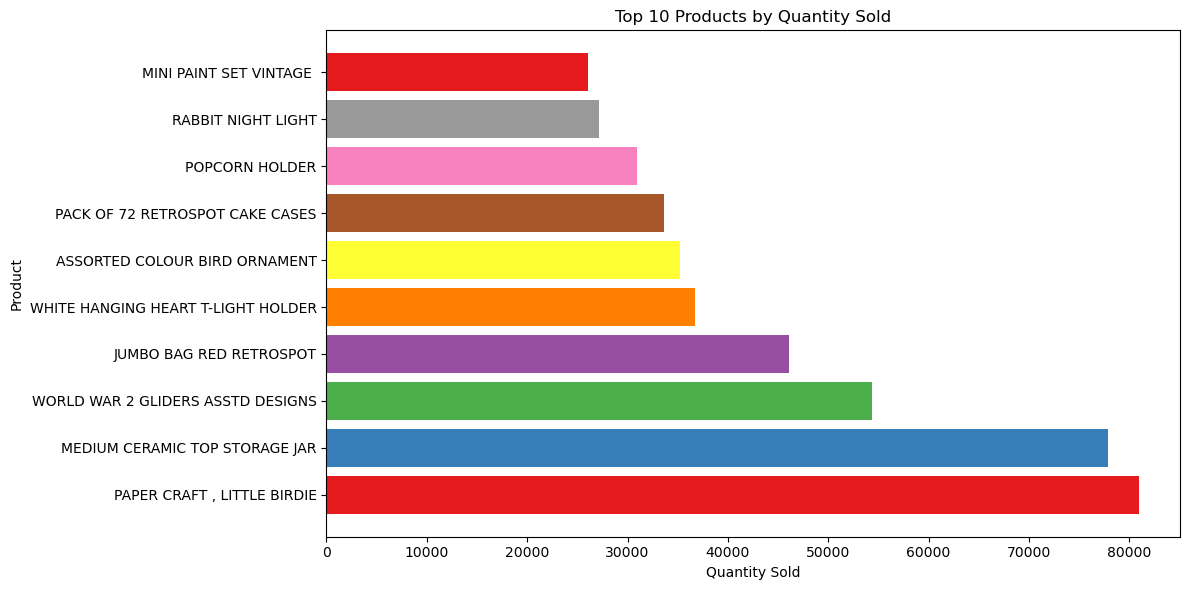

In [23]:
# Visualization

plt.figure(figsize=(12, 6))
colors = sns.color_palette("Set1", n_colors=len(df))

plt.barh(top_products_quantity["Description"],top_products_quantity["Quantity"], color = colors)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

8. Country Analysis

In [24]:
country_revenue = (df.groupby("Country").agg(Revenue=("Revenue", "sum"),
                    Customers=("CustomerID", "nunique"),Orders=("InvoiceNo", "nunique"))
                    .reset_index().sort_values(by="Revenue",ascending=False))

country_revenue.head(10)

,Country,Revenue,Customers,Orders
35,United Kingdom,7285024.644,3920,16646
23,Netherlands,285446.340,9,94
10,EIRE,265262.460,3,260
14,Germany,228678.400,94,457
13,France,208934.310,87,389
0,Australia,138453.810,9,57
30,Spain,61558.560,30,90
32,Switzerland,56443.950,21,51
3,Belgium,41196.340,25,98
31,Sweden,38367.830,8,36


In [25]:
# Top Countries Excluding United Kingdom


top_countries = (country_revenue[country_revenue["Country"] != "United Kingdom"].head(10))

top_countries

,Country,Revenue,Customers,Orders
23,Netherlands,285446.34,9,94
10,EIRE,265262.46,3,260
14,Germany,228678.40,94,457
13,France,208934.31,87,389
0,Australia,138453.81,9,57
30,Spain,61558.56,30,90
32,Switzerland,56443.95,21,51
3,Belgium,41196.34,25,98
31,Sweden,38367.83,8,36
19,Japan,37416.37,8,19


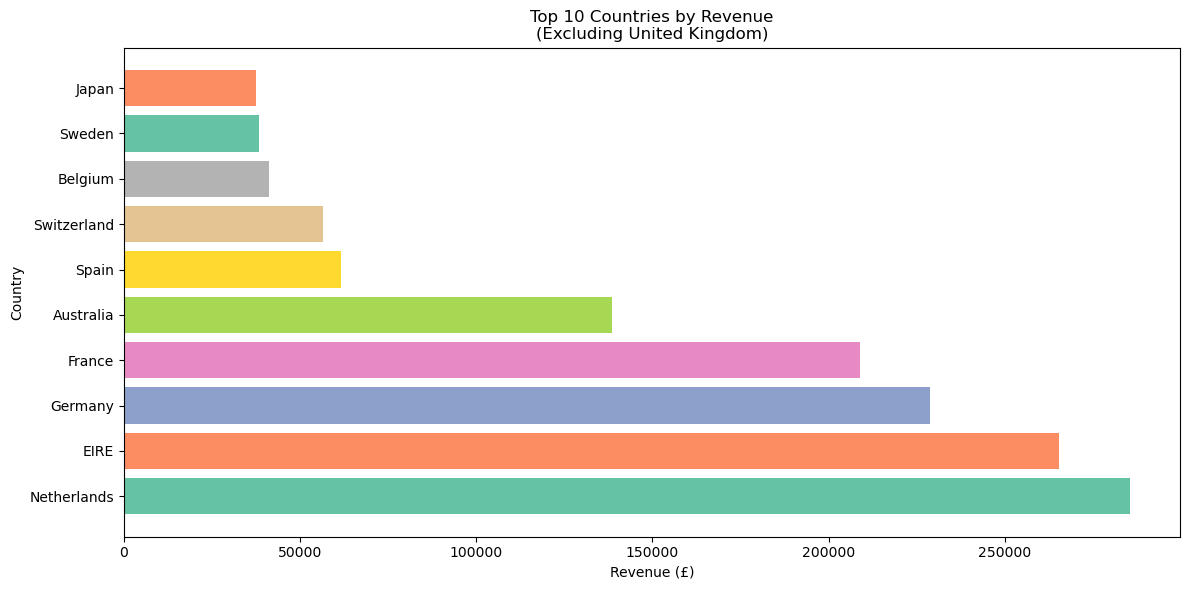

In [26]:
# Visualization

plt.figure(figsize=(12, 6))
colors = sns.color_palette("Set2", n_colors=len(df))

plt.barh(top_countries["Country"],top_countries["Revenue"], color = colors)

plt.title("Top 10 Countries by Revenue\n(Excluding United Kingdom)")

plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

9. Time-Based Analysis

In [27]:
# Revenue by Day of Week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

revenue_by_day = (df.groupby("Day_Name")["Revenue"].sum().reindex(day_order).reset_index())

revenue_by_day

,Day_Name,Revenue
0,Monday,1363604.401
1,Tuesday,1697733.801
2,Wednesday,1584283.830
3,Thursday,1973015.730
4,Friday,1483080.811
5,Saturday,NaN
6,Sunday,785490.321


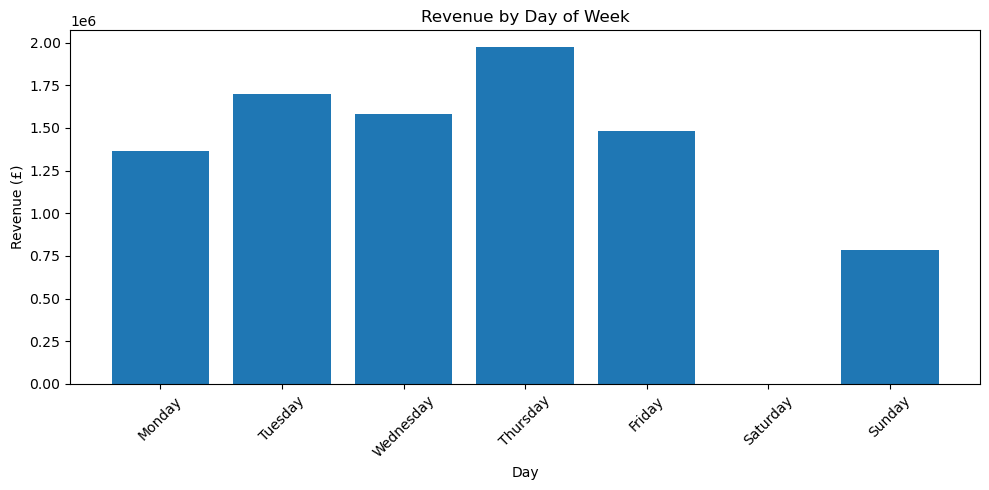

In [28]:
# Visualization

plt.figure(figsize=(10, 5))

plt.bar(revenue_by_day["Day_Name"],revenue_by_day["Revenue"])

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [29]:
# Revenue by Hour

revenue_by_hour = (df.groupby("Hour")["Revenue"].sum().reset_index())

revenue_by_hour

,Hour,Revenue
0,6,4.250
1,7,31059.210
2,8,281997.790
3,9,842392.341
4,10,1259267.591
5,11,1101177.600
6,12,1373695.390
7,13,1168724.200
8,14,991992.821
9,15,963559.680


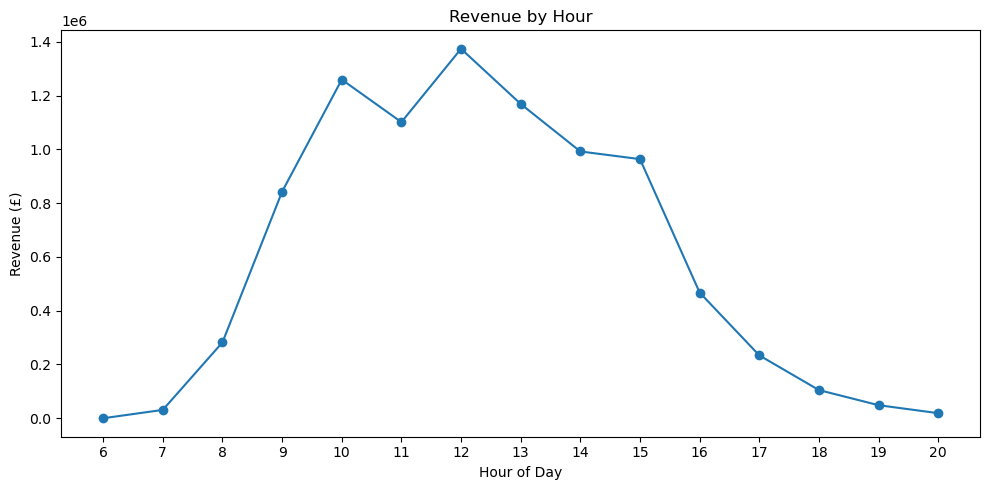

In [30]:
# Visualization

plt.figure(figsize=(10, 5))

plt.plot(revenue_by_hour["Hour"],revenue_by_hour["Revenue"],marker="o")

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")

plt.xticks(range(df["Hour"].min(),df["Hour"].max() + 1))

plt.tight_layout()

plt.show()

10. Customer Purchase Behavior

In [31]:
customer_purchase_behavior = (df.groupby("CustomerID").agg(Total_Orders=("InvoiceNo", "nunique"),
                               Total_Revenue=("Revenue", "sum"),Total_Quantity=("Quantity", "sum")).reset_index())

customer_purchase_behavior.describe()

,CustomerID,Total_Orders,Total_Revenue,Total_Quantity
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,4.272015,2048.688081,1187.644537
std,1721.808492,7.697998,8985.230220,5043.619654
min,12346.000000,1.000000,3.750000,1.000000
25%,13813.250000,1.000000,306.482500,159.000000
50%,15299.500000,2.000000,668.570000,378.000000
75%,16778.750000,5.000000,1660.597500,989.750000
max,18287.000000,209.000000,280206.020000,196915.000000


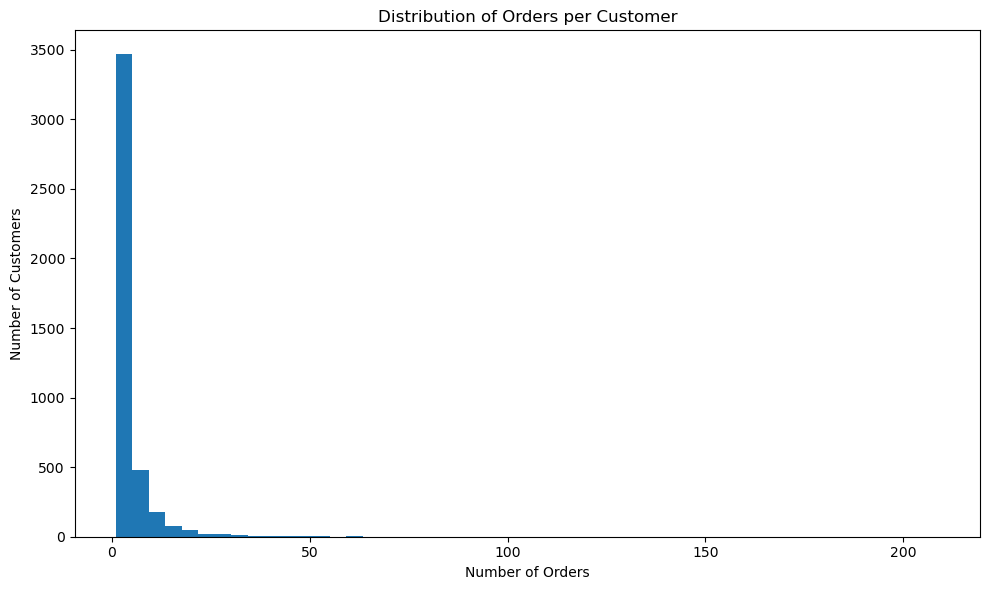

In [32]:
# Distribution of Orders per Customer

plt.figure(figsize=(10, 6))

plt.hist(customer_purchase_behavior["Total_Orders"],bins=50)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

In [33]:
# percentile

customer_purchase_behavior[ "Total_Orders"].describe(percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99])

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
90%         9.000000
95%        13.000000
99%        30.000000
max       209.000000
Name: Total_Orders, dtype: float64

11. Revenue Concentration — Pareto Analysis

In [34]:
customer_pareto = (customer_revenue[["CustomerID", "Total_Revenue"]]
                    .sort_values(by="Total_Revenue",ascending=False).reset_index(drop=True))

customer_pareto["Cumulative_Revenue"] = (customer_pareto["Total_Revenue"].cumsum())

total_revenue = ( customer_pareto["Total_Revenue"].sum())

customer_pareto["Cumulative_Revenue_%"] = ( customer_pareto["Cumulative_Revenue"]/ total_revenue * 100)

customer_pareto.head()

,CustomerID,Total_Revenue,Cumulative_Revenue,Cumulative_Revenue_%
0,14646,280206.02,280206.02,3.152914
1,18102,259657.30,539863.32,6.074610
2,17450,194390.79,734254.11,8.261920
3,16446,168472.50,902726.61,10.157594
4,14911,143711.17,1046437.78,11.774650


In [35]:
customers_80 = customer_pareto[customer_pareto["Cumulative_Revenue_%"] <= 80]

percentage_customers = (len(customers_80) / total_customers) * 100

print(f"{percentage_customers:.2f}% of customers "f"generate approximately 80% of revenue.")

26.03% of customers generate approximately 80% of revenue.


 12. EDA Summary

In [36]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Repeat Customer Rate",
        "Unique Products",
        "Countries"
    ],
    
    "Value": [
        f"£{total_revenue:,.2f}",
        total_orders,
        total_customers,
        f"£{average_order_value:,.2f}",
        f"{repeat_customer_rate:.2f}%",
        total_products,
        df["Country"].nunique()
    ]
})

eda_summary

,Metric,Value
0,Total Revenue,"£8,887,208.89"
1,Total Orders,18532
2,Total Customers,4338
3,Average Order Value,£479.56
4,Repeat Customer Rate,65.58%
5,Unique Products,3665
6,Countries,37


Key Business Insights

1. Total revenue generated during the analysis period was £8,887,208.89

2. The business served 4338 unique customers.

3. 65.58% of customers made more than one purchase.

4. The highest revenue was generated in Month 2011-11 with £1,156,205.610.

5. Customer_id 14646 generated the highest individual revenue of 280206.02 .

6. Product X generated the highest revenue.

7. A small 26.03 % of customers contributed approximately 80% of revenue.

8. The highest purchasing activity occurred during 12PM hour/day.